# Assignment 11.2 - LLMs



## Task 11.2.1: Word Embedding Model

Build and training a small transformer embedding model on example text data. It should encode words into an embedding space where similar words are close to each other.

* Set up a small Transformer model, i.e., using `PyTorch`. **(RESULT)**
* Train the model on a small text corpus, e.g., generated yourself or from the web. **(RESULT)**
* Visualize the learned word embeddings using `t-SNE` or `PCA` in a 2D plot. **(RESULT)**

Make sure to use positional encodings in your transformer model to capture word order information.

Using device: cpu
Vocab size: 74
Example vocab items: ['<pad>', '<mask>', '<unk>', 'a', 'an', 'and', 'animals', 'apple', 'apples', 'are', 'banana', 'bananas', 'berlin', 'bird', 'birds', 'blue', 'bones', 'book', 'bus', 'buses']
Max sentence length: 7
Dataset shapes: torch.Size([40, 7]) torch.Size([40, 7]) torch.Size([40, 7])
TinyTransformerMLM(
  (tok_emb): Embedding(74, 64, padding_idx=0)
  (pos_enc): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementw

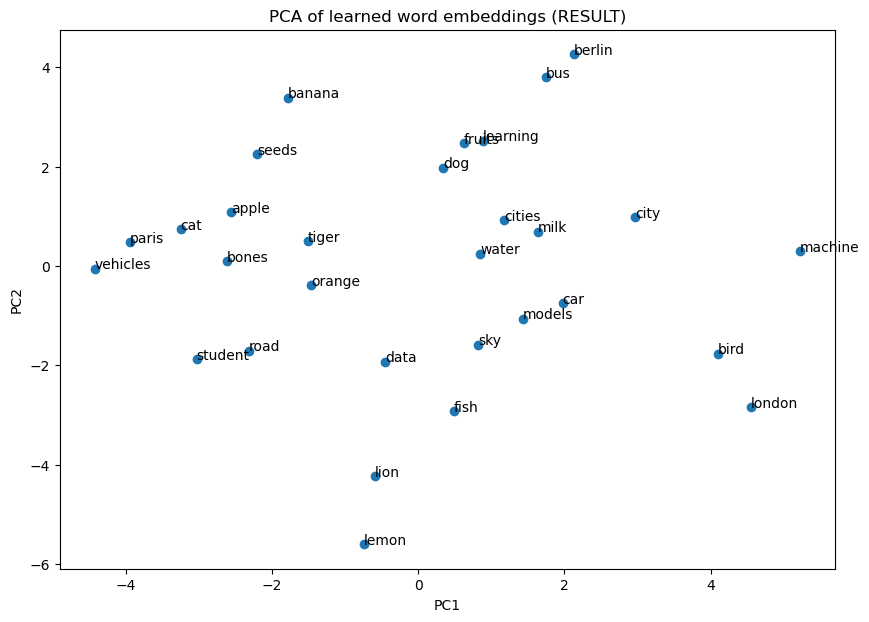

In [ ]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

corpus = [
    "the cat sits on the mat",
    "the dog sits on the rug",
    "the cat and the dog are animals",
    "a lion and a tiger are animals",
    "the lion roars loudly",
    "the tiger runs fast",
    "a dog runs fast",
    "a cat runs quietly",
    "birds fly in the sky",
    "a bird flies in the sky",
    "fish swim in the water",
    "a fish swims in water",
    "apples and bananas are fruits",
    "an apple is a fruit",
    "a banana is a fruit",
    "oranges and lemons are fruits",
    "an orange is a fruit",
    "a lemon is a fruit",
    "paris is a city",
    "berlin is a city",
    "london is a city",
    "paris and berlin are cities",
    "a car drives on the road",
    "a bus drives on the road",
    "cars and buses are vehicles",
    "the road is long",
    "the sky is blue",
    "the water is cold",
    "the cat likes milk",
    "the dog likes bones",
    "the bird likes seeds",
    "the fish likes water",
    "milk is white",
    "bananas are yellow",
    "lemons are yellow",
    "oranges are orange",
    "the student studies machine learning",
    "the student reads a book",
    "machine learning uses data",
    "data and models are important",
]

# tokenize (simple whitespace + lowercase)
sentences = [s.lower().split() for s in corpus]

# add special tokens
PAD = "<pad>"
MASK = "<mask>"
UNK = "<unk>"

all_tokens = [tok for sent in sentences for tok in sent]
counts = Counter(all_tokens)

# build vocab (keep all words; small corpus)
vocab = [PAD, MASK, UNK] + sorted(counts.keys())
stoi = {w:i for i,w in enumerate(vocab)}
itos = {i:w for w,i in stoi.items()}
vocab_size = len(vocab)

print("Vocab size:", vocab_size)
print("Example vocab items:", vocab[:20])

def encode(sent):
    return [stoi.get(w, stoi[UNK]) for w in sent]

encoded = [encode(s) for s in sentences]

max_len = max(len(s) for s in encoded)
print("Max sentence length:", max_len)

def pad_to_max(seq, max_len, pad_id):
    return seq + [pad_id] * (max_len - len(seq))

PAD_ID = stoi[PAD]
MASK_ID = stoi[MASK]

X = []
Y = []
ATTN = []

mask_prob = 0.20  # mask 20% of tokens (typical-ish)

for seq in encoded:
    seq_pad = pad_to_max(seq, max_len, PAD_ID)
    attn_mask = [1 if t != PAD_ID else 0 for t in seq_pad]  # 1=real, 0=pad

    # build masked input and labels
    masked = list(seq_pad)
    labels = [-100] * max_len  # ignore index for non-masked tokens

    for i, tok in enumerate(seq_pad):
        if tok == PAD_ID:
            continue
        if random.random() < mask_prob:
            labels[i] = tok
            masked[i] = MASK_ID

    if all(l == -100 for l in labels):
        # mask one random real token
        real_positions = [i for i,t in enumerate(seq_pad) if t != PAD_ID]
        j = random.choice(real_positions)
        labels[j] = seq_pad[j]
        masked[j] = MASK_ID

    X.append(masked)
    Y.append(labels)
    ATTN.append(attn_mask)

X = torch.tensor(X, dtype=torch.long)
Y = torch.tensor(Y, dtype=torch.long)
ATTN = torch.tensor(ATTN, dtype=torch.long)

print("Dataset shapes:", X.shape, Y.shape, ATTN.shape)


from torch.utils.data import DataLoader, TensorDataset
ds = TensorDataset(X, Y, ATTN)
loader = DataLoader(ds, batch_size=16, shuffle=True)


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, L, d_model)
        return x + self.pe[:, :x.size(1), :]


class TinyTransformerMLM(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 64, nhead: int = 4, num_layers: int = 2, dim_ff: int = 128, dropout: float = 0.1, max_len: int = 128):
        super().__init__()
        self.d_model = d_model

        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            activation="relu",
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, attn_mask):
        # x: (B, L)
        # attn_mask: (B, L) with 1 for real tokens, 0 for pad
        h = self.tok_emb(x) * math.sqrt(self.d_model)
        h = self.pos_enc(h)

        # src_key_padding_mask expects True where padding is
        key_padding_mask = (attn_mask == 0)

        h = self.encoder(h, src_key_padding_mask=key_padding_mask)  # (B, L, d_model)
        logits = self.lm_head(h)  # (B, L, vocab_size)
        return logits

model = TinyTransformerMLM(vocab_size=vocab_size, d_model=64, nhead=4, num_layers=2, dim_ff=128, dropout=0.1, max_len=max_len).to(device)
print(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

def train_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total_tokens = 0
    for xb, yb, ab in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        ab = ab.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb, ab)  # (B,L,V)
        loss = F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1), ignore_index=-100)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            mask = (yb.view(-1) != -100)
            total_tokens += mask.sum().item()
            total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset), total_tokens

epochs = 60
for ep in range(1, epochs + 1):
    avg_loss, supervised = train_epoch(model, loader)
    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep:02d}/{epochs} | avg loss: {avg_loss:.4f} | supervised tokens (approx): {supervised}")


emb = model.tok_emb.weight.detach().cpu().numpy()  # (V, d_model)

plot_words = [
    "cat","dog","lion","tiger","bird","fish",
    "apple","banana","orange","lemon","fruits",
    "paris","berlin","london","city","cities",
    "car","bus","vehicles","road",
    "data","models","machine","learning","student",
    "milk","bones","seeds","water","sky"
]
plot_words = [w for w in plot_words if w in stoi]
plot_ids = [stoi[w] for w in plot_words]

X_emb = emb[plot_ids]

# PCA 2D
pca = PCA(n_components=2, random_state=seed)
X_pca = pca.fit_transform(X_emb)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
for i, w in enumerate(plot_words):
    plt.annotate(w, (X_pca[i, 0], X_pca[i, 1]))
plt.title("PCA of learned word embeddings (RESULT)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# t-SNE 2D
tsne = TSNE(n_components=2, random_state=seed, init="pca", learning_rate="auto", perplexity=8)
X_tsne = tsne.fit_transform(X_emb)

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
for i, w in enumerate(plot_words):
    plt.annotate(w, (X_tsne[i, 0], X_tsne[i, 1]))
plt.title("t-SNE of learned word embeddings (RESULT)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()


## Task 11.2.2: Image Embedding Model (BONUS)

Use a pre-trained Vision Transformer (ViT) model (e.g. some suitable model from HuggingFace) to extract image embeddings from a set of images.

* Use a pre-build Vision Transformer model (whatever flavour you like :)) and train it shortly **if necessary** on CIFAR10.**(RESULT)**
* Extract CIFAR10 test image embeddings using your model. **(RESULT)**
* Visualize the extracted image embeddings using `t-SNE` or `PCA` in a 2D plot. **(RESULT)**

Using device: cpu
CIFAR10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Loaded pretrained ViT_B_16 weights.
Epoch 1/1 | train loss: 0.5818 | subset test acc: 82.30%  (RESULT)
Extracted embeddings shape (RESULT): (2000, 768)


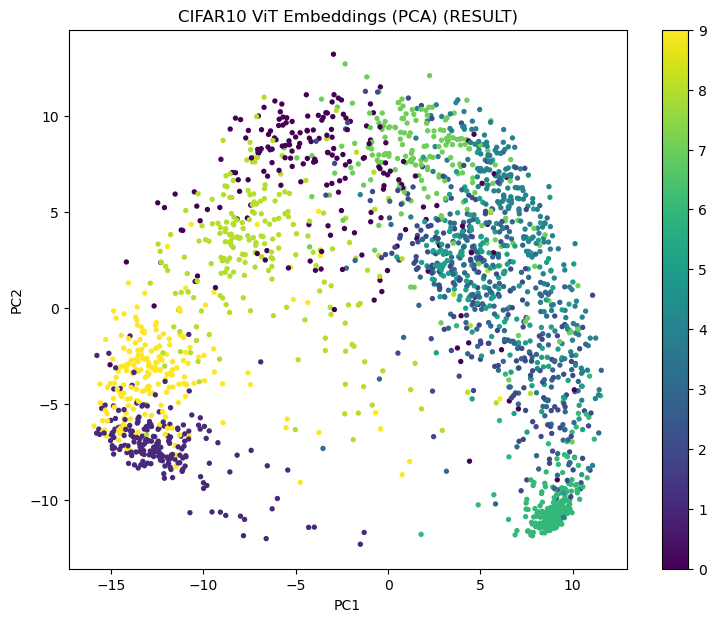

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cifar_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=cifar_transform)
test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=cifar_transform)

train_subset = Subset(train_ds, indices=list(range(0, 5000)))
test_subset  = Subset(test_ds,  indices=list(range(0, 2000)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_subset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

class_names = train_ds.classes
print("CIFAR10 classes:", class_names)

from torchvision.models import vit_b_16, ViT_B_16_Weights

try:
    weights = ViT_B_16_Weights.IMAGENET1K_V1
    vit = vit_b_16(weights=weights)
    print("Loaded pretrained ViT_B_16 weights.")
except Exception as e:
    print("Could not load pretrained weights (falling back to random init). Reason:", repr(e))
    vit = vit_b_16(weights=None)

in_features = vit.heads.head.in_features
vit.heads.head = nn.Linear(in_features, 10)

vit = vit.to(device)

optimizer = torch.optim.AdamW(vit.parameters(), lr=2e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

def eval_acc(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.numel()
    return correct / total

epochs = 1
for ep in range(1, epochs + 1):
    vit.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = vit(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)

    avg_loss = running / len(train_loader.dataset)
    acc = eval_acc(vit, test_loader)
    print(f"Epoch {ep}/{epochs} | train loss: {avg_loss:.4f} | subset test acc: {acc*100:.2f}%  (RESULT)")

def extract_vit_embeddings(model, xb):
    model.eval()
    with torch.no_grad():
        if hasattr(model, "forward_features"):
            feats = model.forward_features(xb)
            if isinstance(feats, dict):
                # try common key
                feats = feats.get("x", None) or feats.get("last_hidden_state", None)
        else:
            x = model._process_input(xb)
            n = x.shape[0]
            cls = model.class_token.expand(n, -1, -1)
            x = torch.cat([cls, x], dim=1)
            x = x + model.encoder.pos_embedding
            x = model.encoder.dropout(x)
            x = model.encoder.layers(x)
            x = model.encoder.ln(x)
            feats = x[:, 0]  # CLS token

        if feats is not None and feats.dim() == 3:
            feats = feats[:, 0]
        return feats

emb_list = []
lab_list = []

for xb, yb in test_loader:
    xb = xb.to(device)
    feats = extract_vit_embeddings(vit, xb)  # (B, dim)
    emb_list.append(feats.detach().cpu().numpy())
    lab_list.append(yb.numpy())

embeddings = np.concatenate(emb_list, axis=0)
labels = np.concatenate(lab_list, axis=0)

print("Extracted embeddings shape (RESULT):", embeddings.shape)

#PCA
pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(emb_pca[:, 0], emb_pca[:, 1], c=labels, s=8)
plt.title("CIFAR10 ViT Embeddings (PCA) (RESULT)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, ticks=range(10))
plt.show()

# t-SNE (use subset for speed)
subset_n = min(1500, embeddings.shape[0])
idx = np.random.RandomState(42).choice(embeddings.shape[0], size=subset_n, replace=False)

tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto", perplexity=30)
emb_tsne = tsne.fit_transform(embeddings[idx])

plt.figure(figsize=(9, 7))
scatter = plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=labels[idx], s=10)
plt.title("CIFAR10 ViT Embeddings (t-SNE) (RESULT)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(scatter, ticks=range(10))
plt.show()
